In [1]:
%pip install liac-arff
%pip install xgboost
%pip install shap





[notice] A new release of pip is available: 25.0 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.0 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.0 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Required libraries
import os
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_curve, auc
os.getcwd()


'/Users/odettesaenz/CS329E/FinalProject'

In [3]:
import arff
import pandas as pd
import os

# Set file path for ARFF file
file_path = "/Users/odettesaenz/Downloads/SpeedDating.arff"

# Load ARFF data and convert to DataFrame
with open(file_path, "r") as f:
    data = arff.load(f)

df = pd.DataFrame(data["data"], columns=[attr[0] for attr in data["attributes"]])

# Drop rows with missing target values and process target
df = df.dropna(subset=['match'])
target = df['match'].map({'no': 0, 'yes': 1})



In [4]:
print(df.columns)


Index(['has_null', 'wave', 'gender', 'age', 'age_o', 'd_age', 'd_d_age',
       'race', 'race_o', 'samerace',
       ...
       'd_expected_num_interested_in_me', 'd_expected_num_matches', 'like',
       'guess_prob_liked', 'd_like', 'd_guess_prob_liked', 'met', 'decision',
       'decision_o', 'match'],
      dtype='object', length=123)


In [5]:
# Basic info
df.info()

print("Missing values in original dataset:")
# Check for nulls
print(df.isnull().sum())

# Example: describe numeric features
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8378 entries, 0 to 8377
Columns: 123 entries, has_null to match
dtypes: float64(59), object(64)
memory usage: 7.9+ MB
Missing values in original dataset:
has_null                0
wave                    0
gender                  0
age                    95
age_o                 104
                     ... 
d_guess_prob_liked      0
met                   375
decision                0
decision_o              0
match                   0
Length: 123, dtype: int64


,wave,age,age_o,d_age,importance_same_race,importance_same_religion,pref_o_attractive,pref_o_sincere,pref_o_intelligence,pref_o_funny,...,music,shopping,yoga,interests_correlate,expected_happy_with_sd_people,expected_num_interested_in_me,expected_num_matches,like,guess_prob_liked,met
count,8378.000000,8283.000000,8274.000000,8378.000000,8299.000000,8299.000000,8289.000000,8289.000000,8289.000000,8280.000000,...,8299.000000,8299.000000,8299.000000,8220.000000,8277.000000,1800.000000,7205.000000,8138.000000,8069.000000,8003.000000
mean,11.350919,26.358928,26.364999,4.185605,3.784793,3.651645,22.495347,17.396867,20.270759,17.459714,...,7.851066,5.631281,4.339197,0.196010,5.534131,5.570556,3.207814,6.134087,5.207523,0.049856
std,5.995903,3.566763,3.563648,4.596171,2.845708,2.805237,12.569802,7.044003,6.782895,6.085526,...,1.791827,2.608913,2.717612,0.303539,1.734059,4.762569,2.444813,1.841285,2.129565,0.282168
min,1.000000,18.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,0.000000,-0.830000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7.000000,24.000000,24.000000,1.000000,1.000000,1.000000,15.000000,15.000000,17.390000,15.000000,...,7.000000,4.000000,2.000000,-0.020000,5.000000,2.000000,2.000000,5.000000,4.000000,0.000000
50%,11.000000,26.000000,26.000000,3.000000,3.000000,3.000000,20.000000,18.370000,20.000000,18.000000,...,8.000000,6.000000,4.000000,0.210000,6.000000,4.000000,3.000000,6.000000,5.000000,0.000000
75%,15.000000,28.000000,28.000000,5.000000,6.000000,6.000000,25.000000,20.000000,23.810000,20.000000,...,9.000000,8.000000,7.000000,0.430000,7.000000,8.000000,4.000000,7.000000,7.000000,0.000000
max,21.000000,55.000000,55.000000,37.000000,10.000000,10.000000,100.000000,60.000000,50.000000,50.000000,...,10.000000,10.000000,10.000000,0.910000,10.000000,20.000000,18.000000,10.000000,10.000000,8.000000


Index(['has_null', 'wave', 'gender', 'age', 'age_o', 'd_age', 'd_d_age',
       'race', 'race_o', 'samerace',
       ...
       'd_expected_num_interested_in_me', 'd_expected_num_matches', 'like',
       'guess_prob_liked', 'd_like', 'd_guess_prob_liked', 'met', 'decision',
       'decision_o', 'match'],
      dtype='object', length=123)
d_like column is missing!


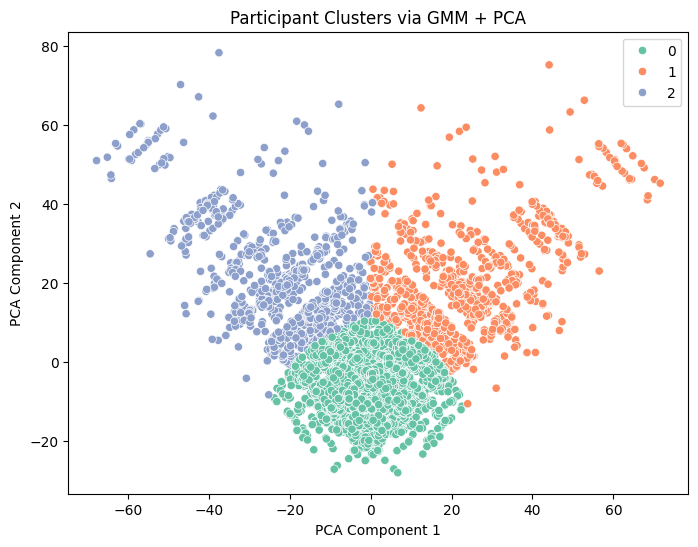

ValueError: zero-size array to reduction operation fmin which has no identity

<Figure size 800x600 with 0 Axes>

In [22]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import shap

from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, auc, confusion_matrix

# Load CSV data
csv_file_path = "/Users/odettesaenz/Downloads/SpeedDating.csv"
df = pd.read_csv(csv_file_path)

# Print the columns to check what's available
print(df.columns)

# Drop missing target and map to binary
df = df.dropna(subset=['match'])
df['match'] = df['match'].map({b'no': 0, b'yes': 1})

# Convert object columns to numeric where possible
df_numeric = df.apply(pd.to_numeric, errors='coerce')

# Select only numeric columns
X_raw = df_numeric.select_dtypes(include='number')

# Step 2: Keep only numeric columns with at least one non-null value
X_raw = X_raw.loc[:, X_raw.notnull().any()]

# Step 3: Impute remaining missing values using mean strategy
imputer = SimpleImputer(strategy='mean')
X_imputed_array = imputer.fit_transform(X_raw)
X_imputed = pd.DataFrame(X_imputed_array, columns=X_raw.columns)

# Step 4: Engineered features
X_imputed['age_diff'] = abs(X_imputed['age'] - X_imputed['age_o'])

# Instead of using 'd_like', ensure correct reference and handle missing values
if 'd_like' in X_imputed.columns:
    X_imputed['like_diff'] = abs(X_imputed['like'] - X_imputed['d_like'])  # Use 'd_like'
else:
    print("d_like column is missing!")
    # Handle the missing column, either by skipping or creating a default behavior
    X_imputed['like_diff'] = 0  # Default to 0 or another value based on your need

# Optional: same_race indicator from original df if 'race' and 'race_o' exist
if 'race' in df.columns and 'race_o' in df.columns:
    X_imputed['same_race'] = (df['race'] == df['race_o']).astype(int).reset_index(drop=True)

# Final features and labels
X_full = X_imputed.reset_index(drop=True)
y = df['match'].reset_index(drop=True)

# PCA for dimensionality reduction before clustering
X_pca = PCA(n_components=2, random_state=42).fit_transform(X_full)

# GMM Clustering
gmm = GaussianMixture(n_components=3, random_state=42)
clusters = gmm.fit_predict(X_pca)
df['cluster'] = clusters

# Visualize clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters, palette='Set2')
plt.title("Participant Clusters via GMM + PCA")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

# Heatmap of match rates by race
heatmap_data = df.pivot_table(index='race', columns='race_o', values='match', aggfunc='mean')
plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data, cmap='coolwarm', annot=True)
plt.title("Match Rates by Race Combinations")
plt.xlabel("Partner's Race")
plt.ylabel("Participant's Race")
plt.show()

print(heatmap_data)
if heatmap_data.empty:
    print("Heatmap data is empty!")

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_full, y, test_size=0.2, random_state=42)

# Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Report:")
print(classification_report(y_test, y_pred_rf))
print("Random Forest ROC AUC Score:", roc_auc_score(y_test, y_pred_rf))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_rf)
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {auc(fpr, tpr):.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest ROC Curve')
plt.legend(loc="lower right")
plt.show()

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')
plt.show()

# SHAP Feature Importance
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_train)
shap.summary_plot(shap_values[1], X_train)

# XGBoost (Optional)
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Report:")
print(classification_report(y_test, y_pred_xgb))
print("XGBoost ROC AUC Score:", roc_auc_score(y_test, y_pred_xgb))

# XGBoost SHAP feature importance
explainer_xgb = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb.shap_values(X_train)
shap.summary_plot(shap_values_xgb, X_train)
